# Singular Spectral Analysis on ECG

> From "Analysis of Time Series Structure: SSA and Related Techniques" by Nina Golyandina et al.

> For documentation details, click [here](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.linalg.hankel.html)

> For theoretical details, click [here](https://en.wikipedia.org/wiki/Hankel_matrix)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, wget
import pyedflib  # to read EDF files

import neurokit2 as nk  # for ECG preprocessing and segmentation

from scipy.linalg import svd
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from collections import defaultdict

In [2]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

## SSA Methodology

In [3]:
# Step 1: Embedding
def embed(time_series, L):
    N = len(time_series)
    K = N - L + 1
    return sliding_window_view(time_series, window_shape=L).T  # shape (L, K)

# Step 2: SVD

# Step 3: Grouping/Clustering
def reconstruct_component(U, s, Vh, indices):
    component = sum(s[i] * np.outer(U[:, i], Vh[i, :]) for i in indices)
    return component

# Step 4: Diagonal averaging (Hankelization)
def diagonal_averaging(X):
    L, K = X.shape
    N = L + K - 1
    reconstructed = np.zeros(N)
    counts = np.zeros(N)

    for i in range(L):
        for j in range(K):
            reconstructed[i + j] += X[i, j]
            counts[i + j] += 1

    return reconstructed / counts

## SSA with syntetic data

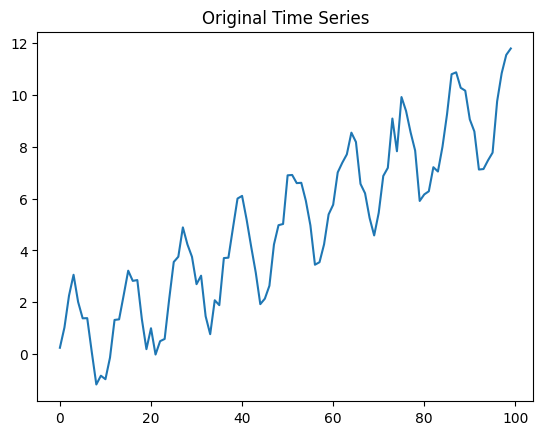

In [4]:
# Let's generate sample time series (trend + seasonality + noise)
np.random.seed(42)
N = 100
t = np.arange(N)
trend = t * 0.1
seasonality = 2 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(0, 0.5, N)
ts = trend + seasonality + noise

plt.plot(ts)
plt.title("Original Time Series")
plt.show()


In [5]:
L = 30  # window length
X = embed(ts, L)
print(f"Trajectory matrix shape: {X.shape}")


Trajectory matrix shape: (30, 71)


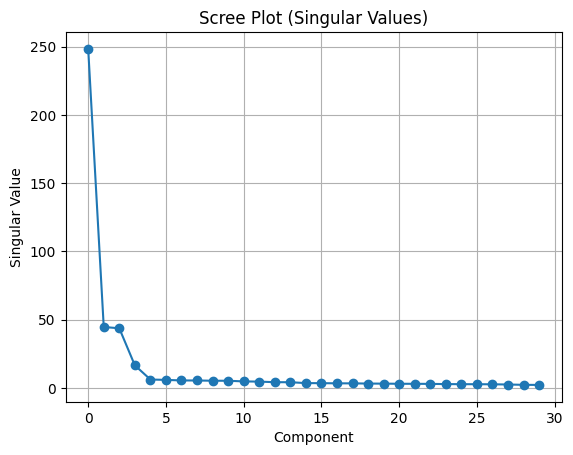

In [6]:
U, s, Vh = svd(X, full_matrices=False)
d = len(s)  # rank

# Plot singular values (scree plot)
plt.plot(s, marker='o')
plt.title("Scree Plot (Singular Values)")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

In [7]:
X_trend = reconstruct_component(U, s, Vh, [0])        # Group 1
X_seasonal = reconstruct_component(U, s, Vh, [1, 2])  # Group 2

In [8]:
ts_trend = diagonal_averaging(X_trend)
ts_seasonal = diagonal_averaging(X_seasonal)
ts_reconstructed = ts_trend + ts_seasonal

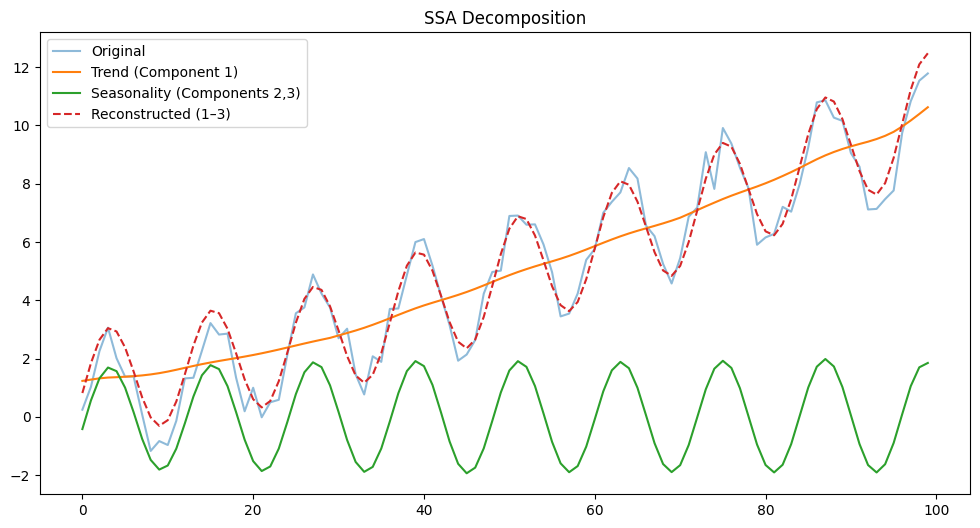

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(ts, label="Original", alpha=0.5)
plt.plot(ts_trend, label="Trend (Component 1)")
plt.plot(ts_seasonal, label="Seasonality (Components 2,3)")
plt.plot(ts_reconstructed, '--', label="Reconstructed (1–3)")
plt.legend()
plt.title("SSA Decomposition")
plt.show()

## SSA with composite ECG signals

In [10]:
edf_file = "r01.edf"
edf_path = os.path.join("..", "data", "raw", edf_file)
plot_fig_path = os.path.join("..", "reports", "figures", "3-singular-spectral-analysis")

In [11]:
# Load EDF file
edf = pyedflib.EdfReader(edf_path)

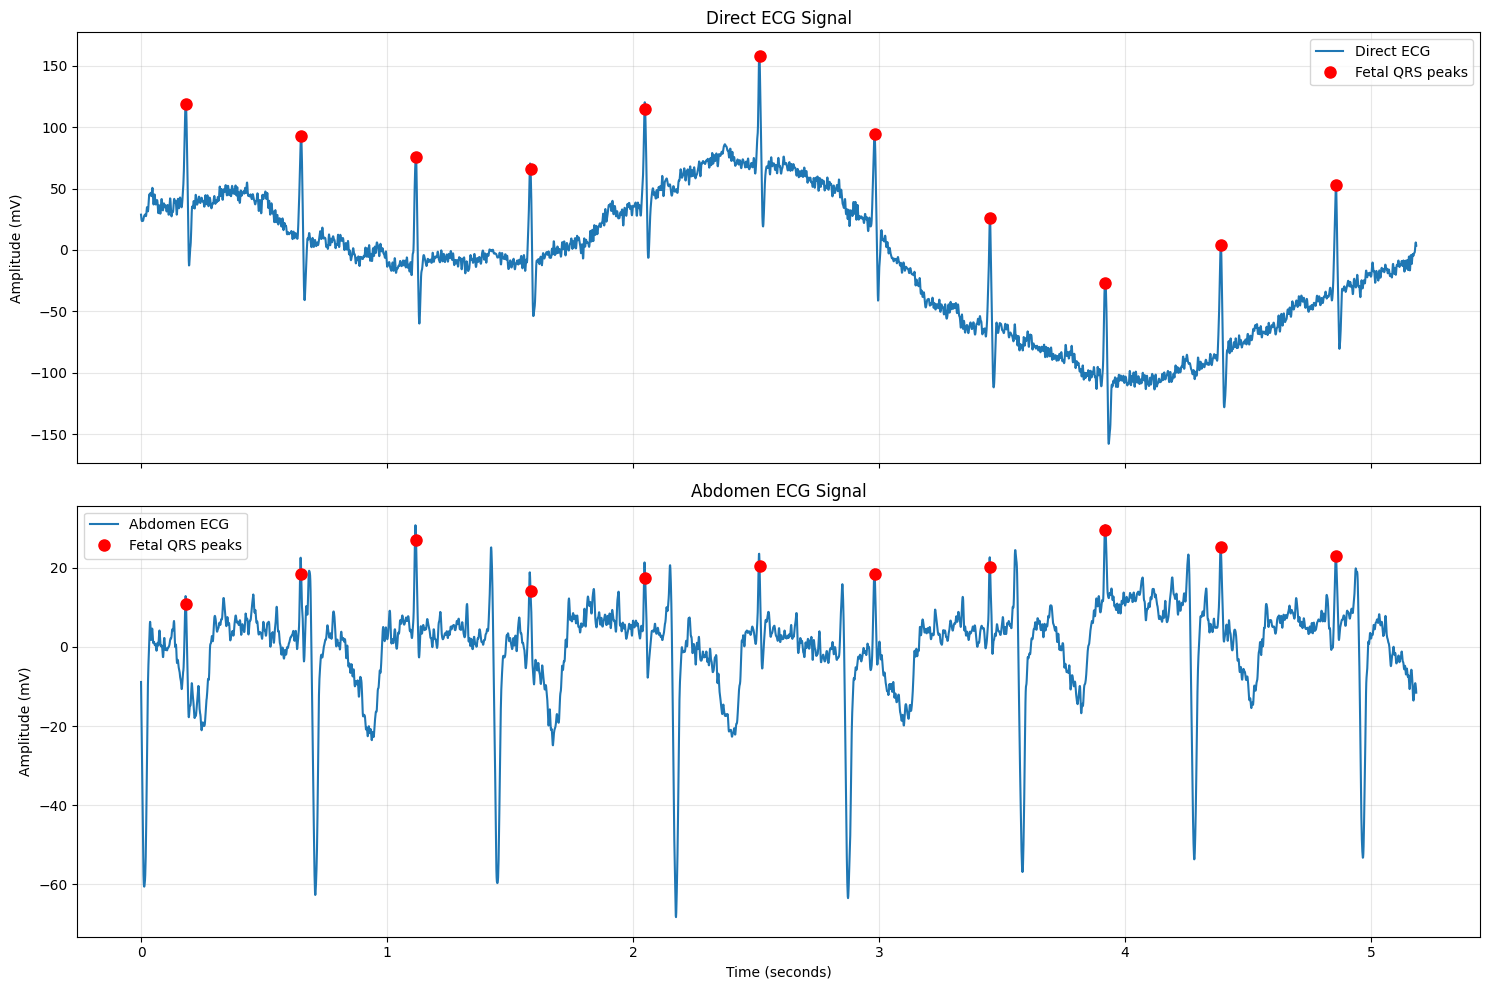

In [12]:
sampling_rate = edf.getSampleFrequency(0)

direct_signal = edf.readSignal(0) # 0 = Direct
abdomen_signal = edf.readSignal(1) # 1 = Abdomen_1, 2 = Abdomen_2, 3 = Abdomen_3, 4 = Abdomen_4
onsets, durations, labels = edf.readAnnotations()

first_onset = onsets[0]
first_label = labels[0]
window_duration = 5.0 # Let's use a bigger window (e.g. 5 or 7 seconds)
start_time = max(0, first_onset - window_duration)
end_time = first_onset + window_duration

# Convert to sample indices
start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extract the signal segment
direct_signal_segment = direct_signal[start_sample:end_sample]
abdomen_signal_segment = abdomen_signal[start_sample:end_sample]
direct_time_segment = np.linspace(start_time, end_time, len(direct_signal_segment))
abdomen_time_segment = np.linspace(start_time, end_time, len(abdomen_signal_segment)) # This should be the same as direct_time_segment

# Get the onsets within the specified time window and interpolate their values
onsets_in_window = onsets[(onsets >= start_time) & (onsets <= end_time)]
direct_onset_values = np.interp(onsets_in_window, direct_time_segment, direct_signal_segment)
abdomen_onset_values = np.interp(onsets_in_window, abdomen_time_segment, abdomen_signal_segment) # This should be the same as direct_onset_values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Direct signal
ax1.plot(direct_time_segment, direct_signal_segment, label='Direct ECG')
ax1.plot(onsets_in_window, direct_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax1.set_ylabel('Amplitude (mV)')
ax1.set_title(f'Direct ECG Signal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Abdomen signal
ax2.plot(abdomen_time_segment, abdomen_signal_segment, label='Abdomen ECG')
ax2.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude (mV)')
ax2.set_title(f'Abdomen ECG Signal')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
def build_matrix(signal, row_length):
    # Idea: build a matrix where each row corresponds to a segment of the signal
    # Calculate the number of rows based on the signal length and row_length
    n_rows = len(signal) // row_length
    
    # For each row, take row_length samples from the signal (from i*row_length to (i+1)*row_length)
    # if i = 0, it takes signal[0*row_length:(0+1)*row_length]
    # if i = 1, it takes signal[1*row_length:(1+1)*row_length], etc.
    matrix = np.array([signal[i*row_length:(i+1)*row_length] for i in range(n_rows)])
    return matrix

def svr_spectrum(signal, n_min, n_max):
    sv_ratios = []  # To store singular value ratios
    n_values = range(n_min, n_max + 1)  # Generate a range of n values from n_min to n_max
    
    for n in n_values:
        # Build the matrix with the current row_length value n
        A = build_matrix(signal, n)
        if A.shape[0] < 2 or A.shape[1] < 2:
            sv_ratios.append(0)
            continue
        
        U, S, VT = np.linalg.svd(A, full_matrices=False)
        if len(S) >= 2 and S[1] != 0:
            # Calculate the ratio of sigma_2 on sigma
            sv_ratios.append(S[1] / S[0])
        else:
            sv_ratios.append(0)
    
    return list(n_values), sv_ratios

In [14]:
# Parameters
n_min = 375
n_max = 1200

# Compute SVR spectrum
n_vals, svrs = svr_spectrum(abdomen_signal_segment, n_min, n_max)

# Find optimal period (max SVR)
mecg_optimal_index = np.argmin(svrs)
mecg_optimal_period = n_vals[mecg_optimal_index]
print(f"Optimal period length: {mecg_optimal_period} samples (SVR ratio: {svrs[mecg_optimal_index]:.4f})")

Optimal period length: 716 samples (SVR ratio: 0.5378)


In [15]:
L = mecg_optimal_period  # window length based on optimal period
X = embed(abdomen_signal_segment, L)
print(f"Trajectory matrix shape: {X.shape}")

Trajectory matrix shape: (716, 4468)


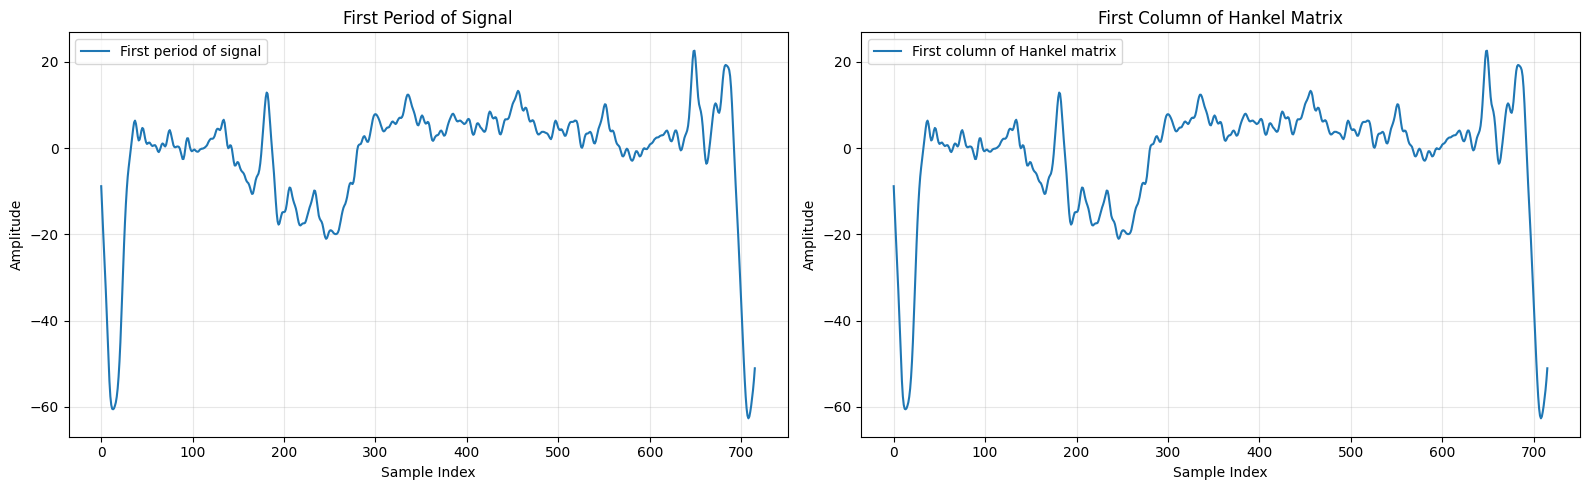

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# First period of signal
axes[0].plot(abdomen_signal_segment[:mecg_optimal_period], label='First period of signal')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('First Period of Signal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# First column of Hankel matrix
axes[1].plot(X[:, 0], label='First column of Hankel matrix')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('First Column of Hankel Matrix')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plot_fig_path, '1-hankel-column.png'))
plt.show()

Number of components to capture 95% energy: 40


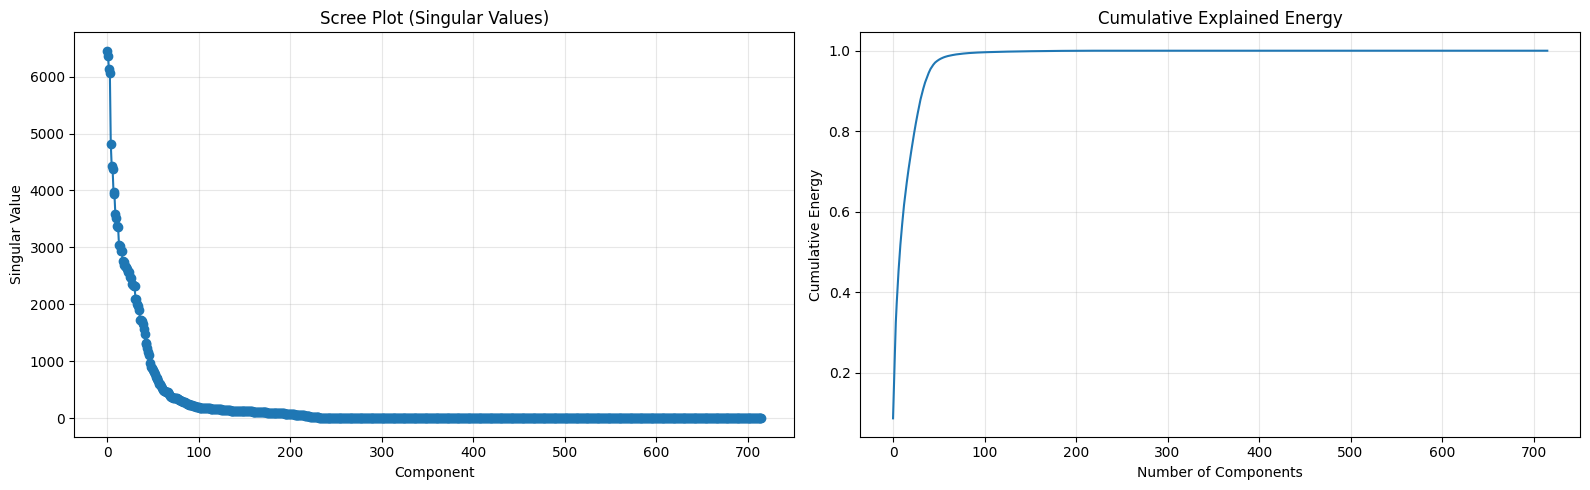

In [17]:
# Step 2: SVD
U, s, Vh = svd(X, full_matrices=False)
d = len(s)  # rank

energy = s**2
relative_energy = energy / np.sum(energy)

k = np.argmax(np.cumsum(relative_energy) > 0.95)
print(f"Number of components to capture 95% energy: {k}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# First period of signal
axes[0].plot(s, marker='o')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('Scree Plot (Singular Values)')
axes[0].grid(True, alpha=0.3)

# First column of Hankel matrix
axes[1].plot(np.cumsum(relative_energy))
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Energy')
axes[1].set_title('Cumulative Explained Energy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.grid(True)
plt.savefig(os.path.join(plot_fig_path, '2-svd-scree.png'))
plt.show()


In [18]:
X = s.reshape(-1, 1)
# I'm supposing that there are 3 main components to cluster (trend, seasonal, noise)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

clusters = defaultdict(list)

for i, label in enumerate(labels):
    clusters[label].append(i)

In [19]:
def reconstruct_component(U, s, Vh, indices):
    return sum(s[i] * np.outer(U[:, i], Vh[i, :]) for i in indices)

# Reconstruct all clusters
X_groups = {label: reconstruct_component(U, s, Vh, idx_list)
            for label, idx_list in clusters.items()}

In [20]:
# Apply to each grouped trajectory matrix
ts_groups = {label: diagonal_averaging(X_group)
             for label, X_group in X_groups.items()}
ts_reconstructed = sum(ts_groups.values())

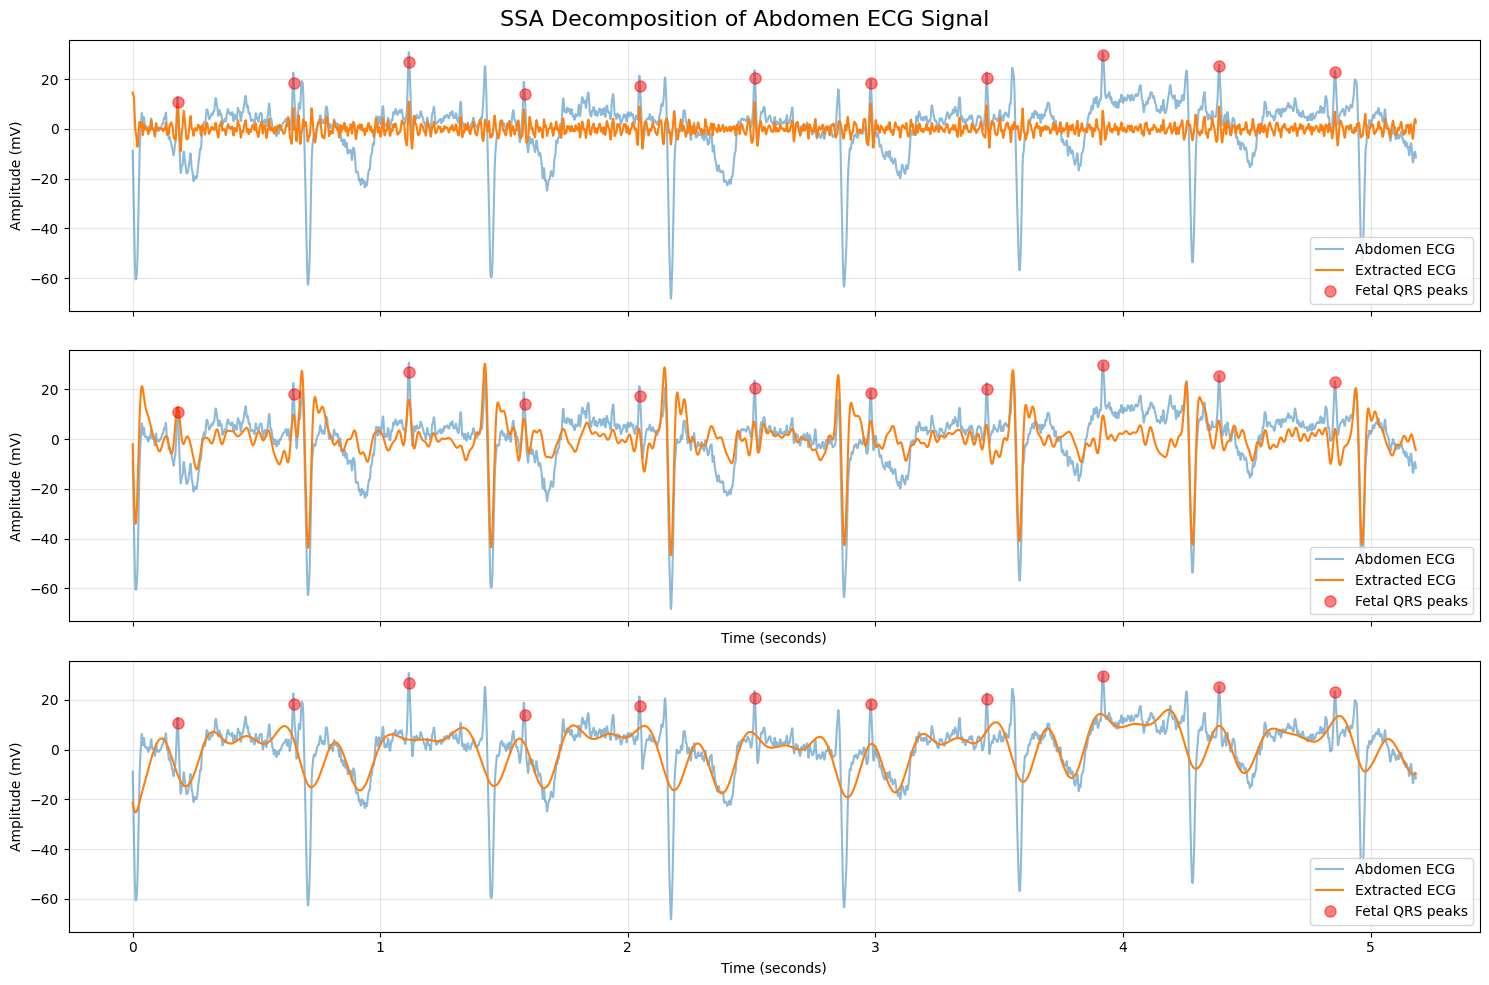

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

fig.suptitle("SSA Decomposition of Abdomen ECG Signal", fontsize=16)

ax1.plot(direct_time_segment, abdomen_signal_segment, label='Abdomen ECG', alpha=0.5)
ax1.plot(direct_time_segment, ts_groups[0], label='Extracted ECG')
ax1.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks", alpha=0.5)
ax2.set_xlabel('Time (seconds)')
ax1.set_ylabel('Amplitude (mV)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Abdomen signal
ax2.plot(abdomen_time_segment, abdomen_signal_segment, label='Abdomen ECG', alpha=0.5)
ax2.plot(direct_time_segment, ts_groups[1], label='Extracted ECG')
ax2.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks", alpha=0.5)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude (mV)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Abdomen signal
ax3.plot(abdomen_time_segment, abdomen_signal_segment, label='Abdomen ECG', alpha=0.5)
ax3.plot(direct_time_segment, ts_groups[2], label='Extracted ECG')
ax3.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks", alpha=0.5)
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Amplitude (mV)')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig(os.path.join(plot_fig_path, '3-ssa-decomposition.png'))
plt.show()